In [2]:
import os
import pandas as pd


reference_df = pd.read_csv(
    "test_predictions_convnext_base_highbias_io_fixedsplit.csv"
)

other_df = pd.read_csv("dataset_lain.csv")


def extract_module_id(path):
    filename = os.path.basename(str(path).replace("\\", "/"))
    filename = os.path.splitext(filename)[0]
    return filename.replace("_80_wrp", "")


reference_df["module_id"] = reference_df["high_path"].apply(
    extract_module_id
)

valid_modules = set(reference_df["module_id"].dropna())

filtered_df = other_df[
    other_df["module"].astype(str).isin(valid_modules)
].copy()

filtered_df.to_csv("dataset_lain_filtered.csv", index=False)

print(f"Rows retained: {len(filtered_df)} / {len(other_df)}")

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_lain.csv'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr


def plot_actual_vs_predicted_with_correlations(
    plot_df,
    actual_col,
    pred_col,
    make_col="Make",
    background_df=None,
    title="Actual vs Predicted",
    xlabel="Actual",
    ylabel="Predicted",
    save_path=None,
    figsize=(9, 7),
    font_size=16,
    marker_size=55,
    background_marker_size=35,
    background_alpha=0.25,
    point_alpha=0.90,
    legend_title="Make",
    show_identity_line=True,
    show_bias=True,
    dpi=300
):
    """
    Plot actual versus predicted values with points coloured by make.

    Metrics shown:
        - Number of samples
        - MAE
        - RMSE
        - Pearson correlation
        - Spearman correlation
        - Bias, optionally

    Parameters
    ----------
    plot_df : pandas.DataFrame
        Main dataframe containing the highlighted data.

    actual_col : str
        Column containing actual/reference values.

    pred_col : str
        Column containing predicted/estimated values.

    make_col : str, default="Make"
        Column used to colour the points.

    background_df : pandas.DataFrame or None
        Optional dataframe plotted in grey as background points.

    font_size : int
        Base font size for title, axes, ticks, metrics, and legend.

    save_path : str or None
        Output image path. If None, the figure is not saved.
    """

    required_cols = [actual_col, pred_col, make_col]

    missing_cols = [
        col for col in required_cols
        if col not in plot_df.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Columns missing from plot_df: {missing_cols}"
        )

    # ---------------------------------------------------------
    # Clean main plotting dataframe
    # ---------------------------------------------------------
    data = plot_df[required_cols].copy()

    data[actual_col] = pd.to_numeric(
        data[actual_col],
        errors="coerce"
    )

    data[pred_col] = pd.to_numeric(
        data[pred_col],
        errors="coerce"
    )

    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=[actual_col, pred_col, make_col])

    if len(data) < 2:
        raise ValueError(
            "At least two valid observations are required."
        )

    y_actual = data[actual_col].to_numpy(dtype=float)
    y_pred = data[pred_col].to_numpy(dtype=float)

    # ---------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    bias = np.mean(y_pred - y_actual)

    try:
        pearson_r, pearson_p = pearsonr(y_actual, y_pred)
    except Exception:
        pearson_r, pearson_p = np.nan, np.nan

    try:
        spearman_r, spearman_p = spearmanr(y_actual, y_pred)
    except Exception:
        spearman_r, spearman_p = np.nan, np.nan

    # ---------------------------------------------------------
    # Global font settings for this figure
    # ---------------------------------------------------------
    plt.rcParams.update({
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size - 2,
        "ytick.labelsize": font_size - 2,
        "legend.fontsize": font_size - 3,
        "legend.title_fontsize": font_size - 2
    })

    fig, ax = plt.subplots(figsize=figsize)

    # ---------------------------------------------------------
    # Optional background points
    # ---------------------------------------------------------
    if background_df is not None:

        background_required = [actual_col, pred_col]

        missing_background_cols = [
            col for col in background_required
            if col not in background_df.columns
        ]

        if missing_background_cols:
            raise ValueError(
                "Columns missing from background_df: "
                f"{missing_background_cols}"
            )

        background = background_df[background_required].copy()

        background[actual_col] = pd.to_numeric(
            background[actual_col],
            errors="coerce"
        )

        background[pred_col] = pd.to_numeric(
            background[pred_col],
            errors="coerce"
        )

        background = background.replace(
            [np.inf, -np.inf],
            np.nan
        )

        background = background.dropna(
            subset=[actual_col, pred_col]
        )

        ax.scatter(
            background[actual_col],
            background[pred_col],
            s=background_marker_size,
            alpha=background_alpha,
            color="lightgrey",
            edgecolors="none",
            label="Background split",
            zorder=1
        )

    # ---------------------------------------------------------
    # Main points coloured by make
    # ---------------------------------------------------------
    makes = sorted(
        data[make_col].unique(),
        key=lambda x: str(x)
    )

    cmap = plt.get_cmap("tab20")

    for i, make in enumerate(makes):

        subset = data[data[make_col] == make]

        ax.scatter(
            subset[actual_col],
            subset[pred_col],
            s=marker_size,
            alpha=point_alpha,
            color=cmap(i % 20),
            edgecolors="white",
            linewidths=0.5,
            label=str(make),
            zorder=3
        )

    # ---------------------------------------------------------
    # Axis limits and identity line
    # ---------------------------------------------------------
    all_x = list(data[actual_col])
    all_y = list(data[pred_col])

    if background_df is not None and len(background) > 0:
        all_x.extend(background[actual_col].tolist())
        all_y.extend(background[pred_col].tolist())

    finite_values = np.asarray(all_x + all_y, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]

    axis_min = np.min(finite_values)
    axis_max = np.max(finite_values)

    axis_range = axis_max - axis_min

    if axis_range == 0:
        axis_range = abs(axis_max) * 0.1
        if axis_range == 0:
            axis_range = 1.0

    padding = 0.05 * axis_range

    lower_limit = axis_min - padding
    upper_limit = axis_max + padding

    ax.set_xlim(lower_limit, upper_limit)
    ax.set_ylim(lower_limit, upper_limit)

    if show_identity_line:
        ax.plot(
            [lower_limit, upper_limit],
            [lower_limit, upper_limit],
            linestyle="--",
            linewidth=1.5,
            color="black",
            label="1:1 line",
            zorder=2
        )

    # ---------------------------------------------------------
    # Metric annotation
    # ---------------------------------------------------------
    metric_lines = [
        f"N = {len(data)}",
        f"MAE = {mae:.4g}",
        f"RMSE = {rmse:.4g}",
        f"Pearson r = {pearson_r:.3f}",
        f"Spearman ρ = {spearman_r:.3f}"
    ]

    if show_bias:
        metric_lines.append(f"Bias = {bias:.4g}")

    metric_text = "\n".join(metric_lines)

    ax.text(
        0.03,
        0.97,
        metric_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=font_size - 1,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "grey",
            "alpha": 0.90
        },
        zorder=5
    )

    # ---------------------------------------------------------
    # Labels and formatting
    # ---------------------------------------------------------
    ax.set_title(
        title,
        fontsize=font_size + 2,
        fontweight="bold",
        pad=12
    )

    ax.set_xlabel(
        xlabel,
        fontsize=font_size
    )

    ax.set_ylabel(
        ylabel,
        fontsize=font_size
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=font_size - 2
    )

    ax.grid(
        True,
        alpha=0.25
    )

    ax.legend(
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        markerscale=1.0
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )
        print(f"Plot saved to: {save_path}")

    plt.show()

    # Return metrics so they can be reused
    metrics = {
        "N": len(data),
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_r,
        "Spearman_p": spearman_p,
        "Bias": bias
    }

    return metrics

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# PATH
# =========================================================
REFERENCE_CSV = "test_predictions_convnext_base_highbias_j0_general3438.csv"
OTHER_DATASET_CSV = "test_predictions_convnext_base_highbias_general3438.csv"
FILTERED_OUTPUT_CSV = "test_predictions_convnext_base_highbias_general3438_filtered.csv"


# =========================================================
# HELPER: extract module id
# =========================================================
def extract_module_id(path):
    """
    Example:
    10085_35_1_02222021_80_wrp.tiff
    -> 10085_35_1_02222021
    """
    if pd.isna(path):
        return None

    filename = os.path.basename(str(path).replace("\\", "/"))
    filename = os.path.splitext(filename)[0]

    suffixes = [
        "_80_wrp", "_20_wrp",
        "_80", "_20",
        "_J0", "_j0",
        "_Rs", "_RS", "_rs",
        "_Io", "_IO", "_io"
    ]

    for suffix in suffixes:
        if filename.endswith(suffix):
            filename = filename[:-len(suffix)]
            break

    return filename


# =========================================================
# 1) READ REFERENCE DATA
# =========================================================
ref_df = pd.read_csv(REFERENCE_CSV)

# module id from reference file
ref_df["module_id"] = ref_df["high_path"].apply(extract_module_id)

# set of valid modules
valid_modules = set(ref_df["module_id"].dropna())

print(f"Jumlah modul unik di reference: {len(valid_modules)}")


# =========================================================
# 2) READ OTHER DATASET
# =========================================================
other_df = pd.read_csv(OTHER_DATASET_CSV)

# ---------------------------------------------------------
# PILIH kolom yang mewakili identitas modul di dataset lain
# ---------------------------------------------------------
# Ganti bagian ini sesuai dataset kamu:
#
# CASE A: kalau dataset lain punya kolom path gambar seperti high_path / ELHPath
# other_df["module_id"] = other_df["high_path"].apply(extract_module_id)
#
# CASE B: kalau dataset lain sudah punya kolom module
# other_df["module_id"] = other_df["module"].astype(str)
#
# CASE C: kalau punya kolom ELHPath
# other_df["module_id"] = other_df["ELHPath"].apply(extract_module_id)
#
# ---------------------------------------------------------

# CONTOH default:
other_df["module_id"] = other_df["high_path"].apply(extract_module_id)


# =========================================================
# 3) FILTER
# =========================================================
filtered_df = other_df[other_df["module_id"].isin(valid_modules)].copy()

filtered_df.to_csv(FILTERED_OUTPUT_CSV, index=False)

print(f"Baris awal dataset lain   : {len(other_df)}")
print(f"Baris setelah difilter    : {len(filtered_df)}")
print(f"Modul unik setelah filter : {filtered_df['module_id'].nunique()}")
print(f"Disimpan ke               : {FILTERED_OUTPUT_CSV}")


# =========================================================
# 5) EXAMPLE PLOT
# =========================================================
# Kalau kamu mau persis seperti chart pojok kanan atas dari file reference:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref_df,
    background_df=None,   # kalau mau ada titik abu-abu, isi dataframe lain
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="make_plot",
    title="Test: High-bias EL + J0 Map",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="chart_pojok_kanan_atas.png"
)

Jumlah modul unik di reference: 25
Baris awal dataset lain   : 47
Baris setelah difilter    : 25
Modul unik setelah filter : 25
Disimpan ke               : test_predictions_convnext_base_highbias_general3438_filtered.csv


NameError: name 'plot_actual_vs_predicted_like_top_right' is not defined

In [4]:

# =========================================================
# 4) FUNCTION: plot like top-right chart
# =========================================================
def compute_r2(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot


def plot_actual_vs_predicted_like_top_right(
    plot_df,
    background_df=None,
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="make_plot",
    title="Test: High-bias EL + J0 Map",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="top_right_style_chart.png",
):
    df = plot_df.copy()

    # kalau make_plot tidak ada, pakai Make
    if make_col not in df.columns:
        if "Make" in df.columns:
            make_col = "Make"
        else:
            df[make_col] = "Unknown"

    y_true = df[actual_col].values
    y_pred = df[pred_col].values

    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    r2 = compute_r2(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    n = len(df)

    fig, ax = plt.subplots(figsize=(8, 7))

    # background split, abu-abu muda
    if background_df is not None:
        bg = background_df.copy()
        ax.scatter(
            bg[actual_col],
            bg[pred_col],
            s=35,
            color="lightgray",
            alpha=0.6,
            edgecolors="none",
            label="Background split"
        )

    # warna per make
    unique_makes = sorted(df[make_col].dropna().unique())
    cmap = plt.cm.get_cmap("tab10", len(unique_makes))

    for i, mk in enumerate(unique_makes):
        sub = df[df[make_col] == mk]
        ax.scatter(
            sub[actual_col],
            sub[pred_col],
            s=45,
            color=cmap(i),
            alpha=0.9,
            edgecolors="none",
            label=str(mk)
        )

    # diagonal
    all_x = pd.concat([
        df[actual_col],
        df[pred_col],
        background_df[actual_col] if background_df is not None else pd.Series(dtype=float),
        background_df[pred_col] if background_df is not None else pd.Series(dtype=float),
    ], ignore_index=True).dropna()

    vmin = all_x.min()
    vmax = all_x.max()
    pad = (vmax - vmin) * 0.05 if vmax > vmin else 0.01

    ax.plot(
        [vmin - pad, vmax + pad],
        [vmin - pad, vmax + pad],
        linestyle="--",
        color="black",
        linewidth=1.5
    )

    ax.set_xlim(vmin - pad, vmax + pad)
    ax.set_ylim(vmin - pad, vmax + pad)

    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.grid(True, alpha=0.3)

    # stats box
    stats_text = (
        f"N = {n}\n"
        f"MAE = {mae:.4f}  ({mae*100:.2f}%)\n"
        f"RMSE = {rmse:.4f}  ({rmse*100:.2f}%)\n"
        f"R² = {r2:.3f}\n"
        f"Bias = {bias:.4f}"
    )

    ax.text(
        0.03, 0.97,
        stats_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=15,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="whitesmoke", edgecolor="gray")
    )

    ax.legend(title="Make", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Chart saved to: {save_path}")



In [ ]:
plot_actual_vs_predicted_like_top_right(
    plot_df=filtered_df,
    background_df=other_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="Filtered Dataset: Actual vs Predicted PF_Voc",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="filtered_dataset_chart.png"
)

In [35]:
FILTERED_OUTPUT_CSV = "test_predictions_convnext_base_highbias_fixedsplit_filtered.csv"

ref_df = pd.read_csv(FILTERED_OUTPUT_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_14048\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


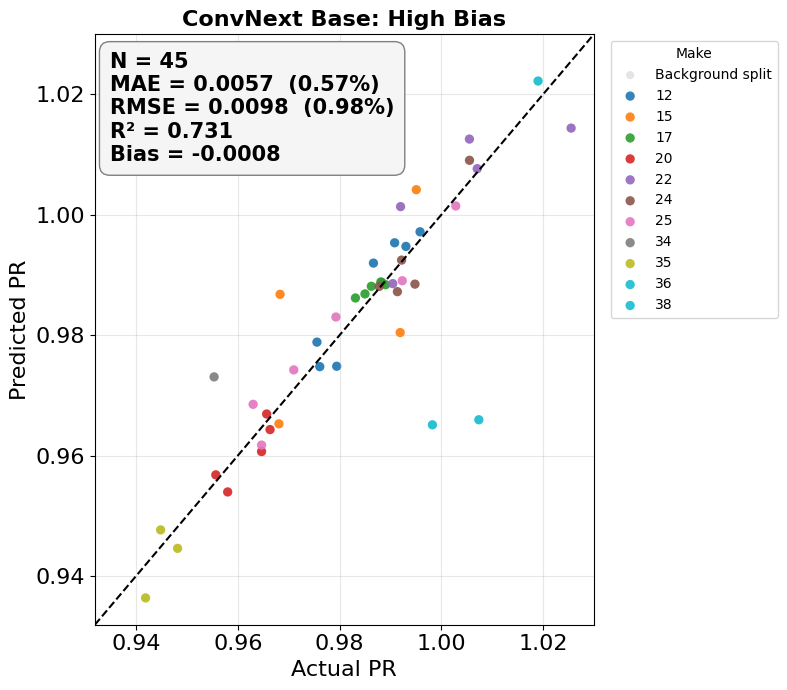

Chart saved to: filtered_dataset_chart.png


In [36]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref_df,
    background_df=ref_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="ConvNext Base: High Bias",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

In [33]:
FILTERED_OUTPUT2_CSV = "test_predictions_convnext_base_dual_fixedsplit_filtered.csv"

ref2_df = pd.read_csv(FILTERED_OUTPUT2_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_14048\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


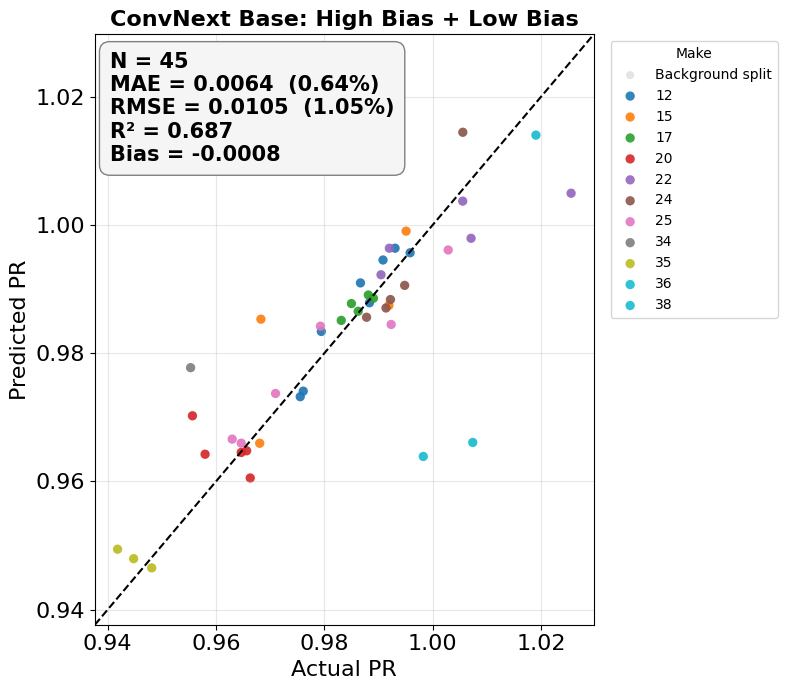

Chart saved to: filtered_dataset_chart.png


In [34]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref2_df,
    background_df=ref2_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="ConvNext Base: High Bias + Low Bias",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

In [12]:
FILTERED_OUTPUT3_CSV = "test_predictions_convnext_base_highbias_j0_trainnorm_fixedsplit.csv"

ref3_df = pd.read_csv(FILTERED_OUTPUT3_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_14048\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


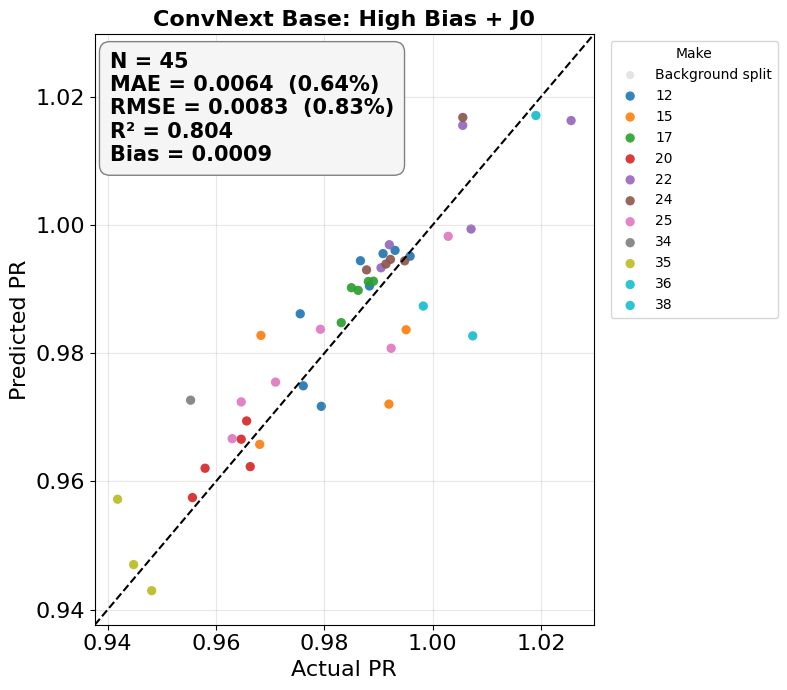

Chart saved to: filtered_dataset_chart.png


In [32]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref3_df,
    background_df=ref3_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="ConvNext Base: High Bias + J0",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

In [38]:
FILTERED_OUTPUT4_CSV = "test_predictions_effnet_b1_dual_fixedsplit_filtered.csv"

ref4_df = pd.read_csv(FILTERED_OUTPUT4_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_14048\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


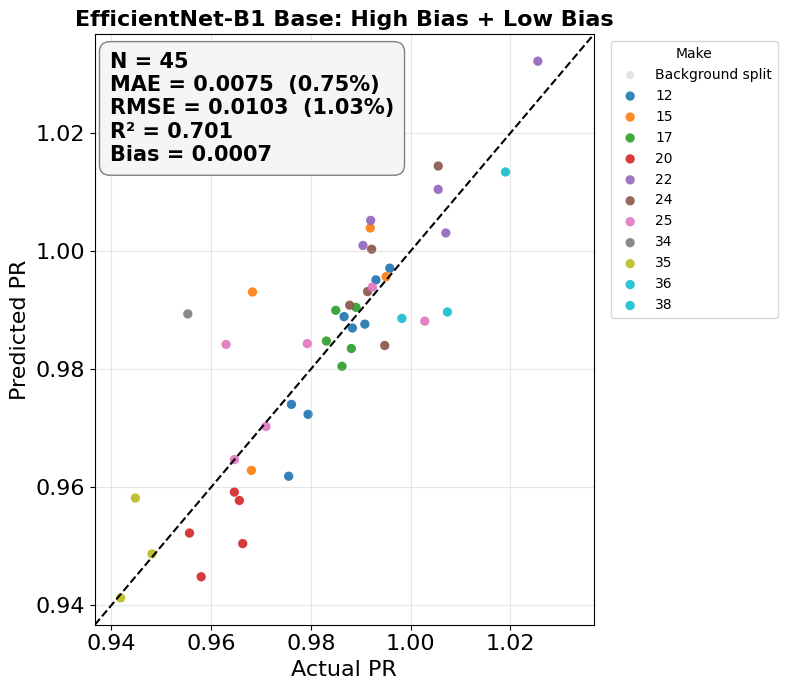

Chart saved to: filtered_dataset_chart.png


In [39]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref4_df,
    background_df=ref4_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="EfficientNet-B1 Base: High Bias + Low Bias",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

In [43]:
FILTERED_OUTPUT5_CSV = "test_predictions_effnet_b1_high_fixedsplit_filtered.csv"

ref5_df = pd.read_csv(FILTERED_OUTPUT5_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_14048\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


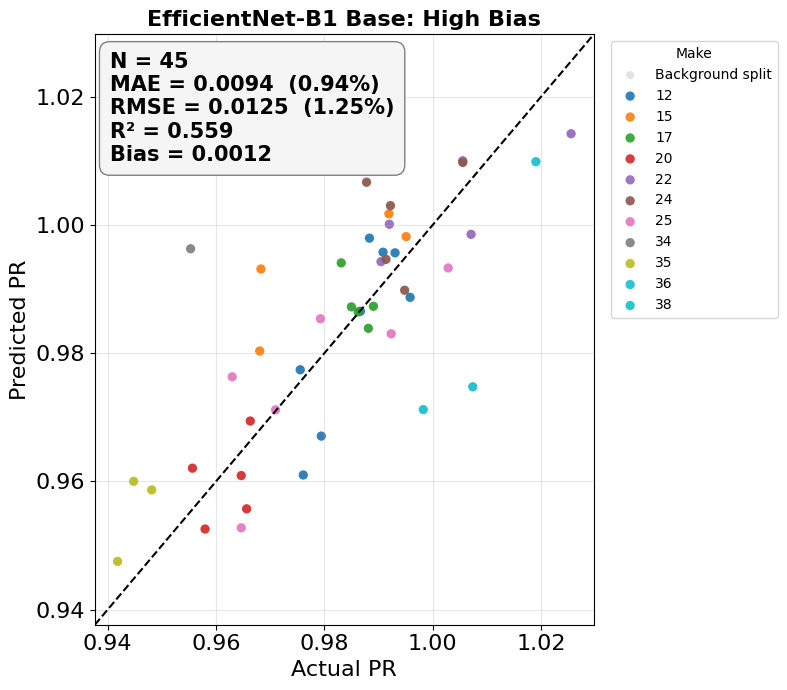

Chart saved to: filtered_dataset_chart.png


In [44]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref5_df,
    background_df=ref5_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="EfficientNet-B1 Base: High Bias",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

In [45]:
FILTERED_OUTPUT6_CSV = "test_predictions_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv"

ref6_df = pd.read_csv(FILTERED_OUTPUT6_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_14048\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


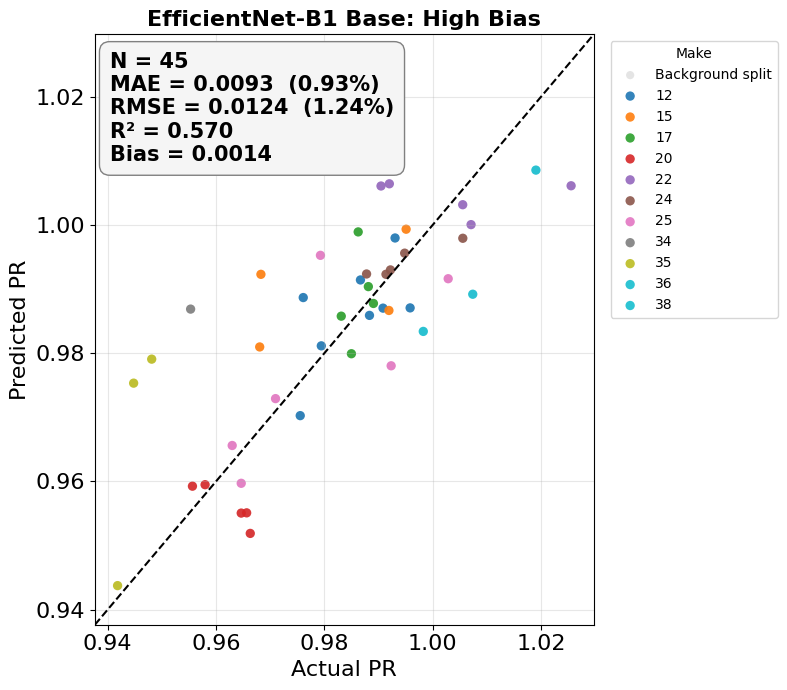

Chart saved to: filtered_dataset_chart.png


In [46]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref6_df,
    background_df=ref6_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="EfficientNet-B1 Base: High Bias",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

In [2]:
FILTERED_OUTPUT7_CSV = "rajput_results_with_PR_PF_Voc_make.csv"

ref7_df = pd.read_csv(FILTERED_OUTPUT7_CSV)

Plot saved to: i0_actual_vs_predicted_correlation.png


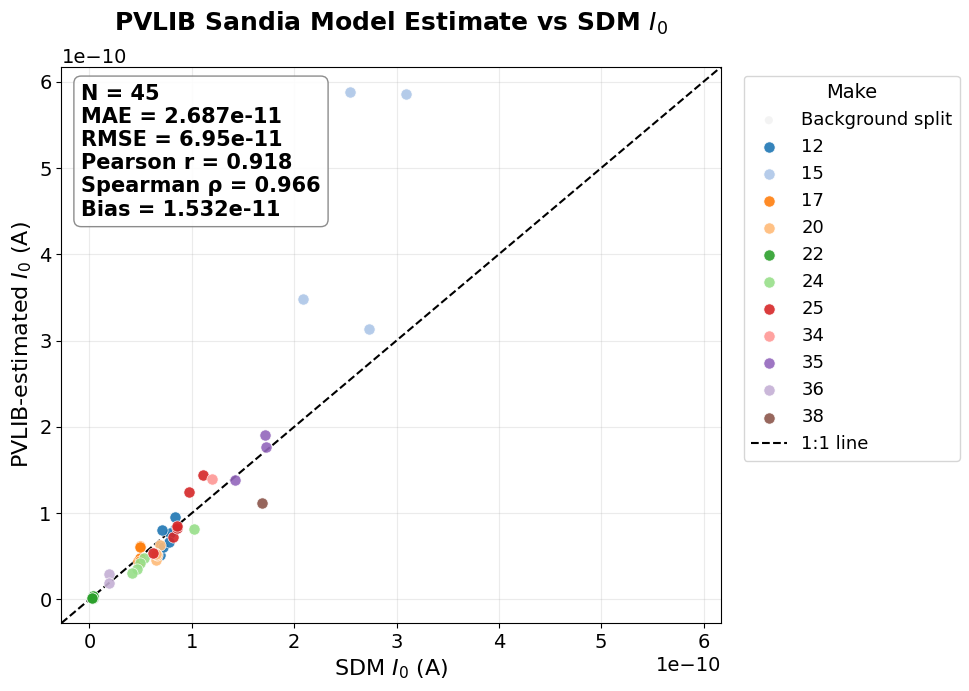

In [3]:
metrics_i0 = plot_actual_vs_predicted_with_correlations(
    plot_df=ref7_df,
    background_df=ref7_df,
    actual_col="I0_diode_A",
    pred_col="I0_pyspice_A",
    make_col="Make",
    title="PVLIB Sandia Model Estimate vs SDM $I_0$",
    xlabel="SDM $I_0$ (A)",
    ylabel="PVLIB-estimated $I_0$ (A)",
    save_path="i0_actual_vs_predicted_correlation.png",
    figsize=(10, 7),
    font_size=16,
    marker_size=65
)

Plot saved to: rs_actual_vs_predicted_correlation.png


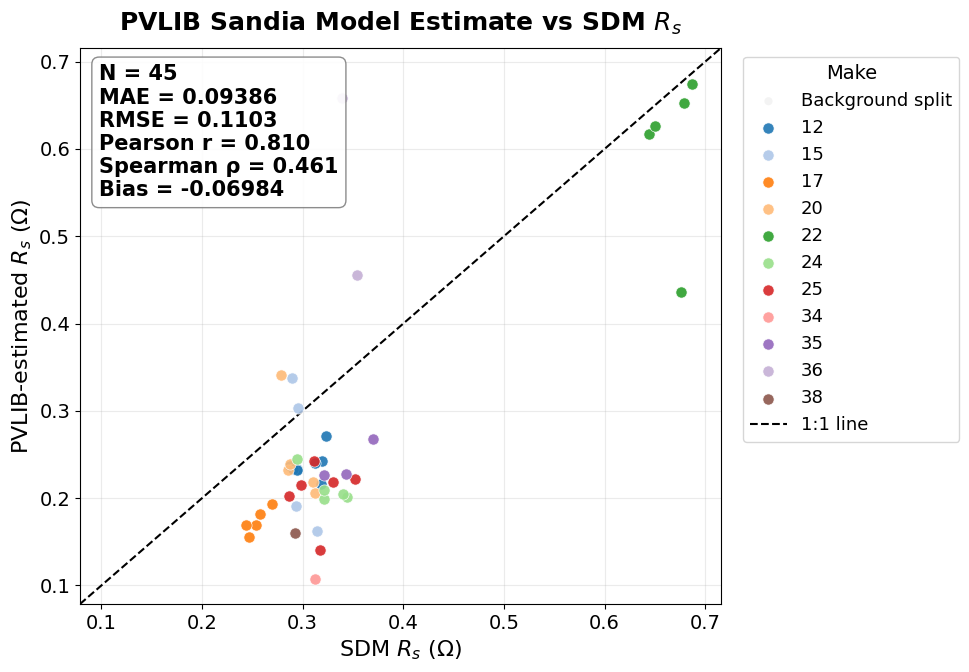

In [4]:
metrics_i0 = plot_actual_vs_predicted_with_correlations(
    plot_df=ref7_df,
    background_df=ref7_df,
    actual_col="Rs_diode_Ohm",
    pred_col="Rs_pyspice_Ohm",
    make_col="Make",
    title="PVLIB Sandia Model Estimate vs SDM $R_s$",
    xlabel="SDM $R_s$ (Ω)",
    ylabel="PVLIB-estimated $R_s$ (Ω)",
    save_path="rs_actual_vs_predicted_correlation.png",
    figsize=(10, 7),
    font_size=16,
    marker_size=65
)

Standar deviasi: 1.8097113498185171 %


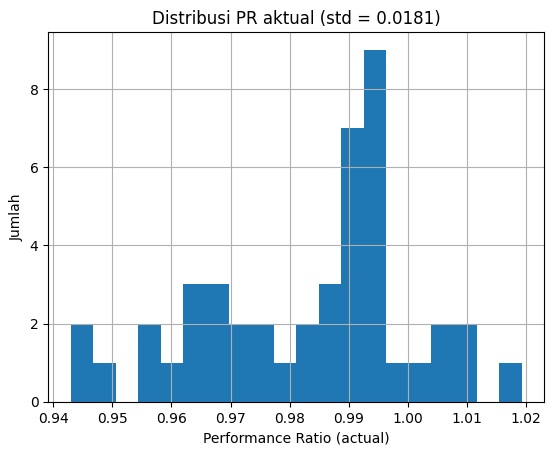

In [50]:
import matplotlib.pyplot as plt

std = ref7_df['PR_measured'].std()
print("Standar deviasi:", std*100, "%")

ref7_df['PR_measured'].hist(bins=20)
plt.xlabel("Performance Ratio (actual)")
plt.ylabel("Jumlah")
plt.title(f"Distribusi PR aktual (std = {std:.4f})")
plt.show()

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_38468\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


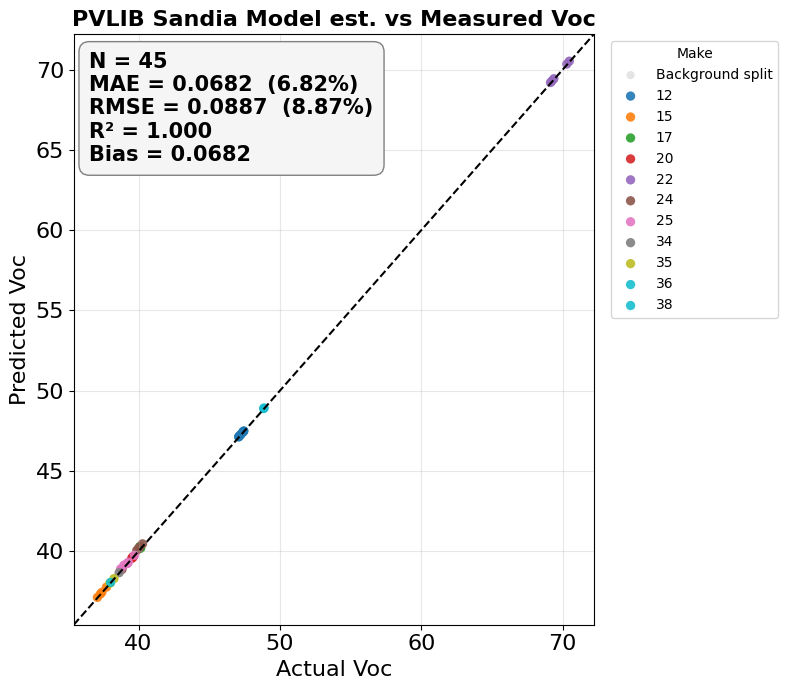

Chart saved to: filtered_dataset_chart.png


In [9]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref7_df,
    background_df=ref7_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="Voc_measured_V",
    pred_col="Voc_diode_V",
    make_col="Make",
    title="PVLIB Sandia Model est. vs Measured Voc",
    xlabel="Actual Voc",
    ylabel="Predicted Voc",
    save_path="filtered_dataset_chart.png"
)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_38468\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


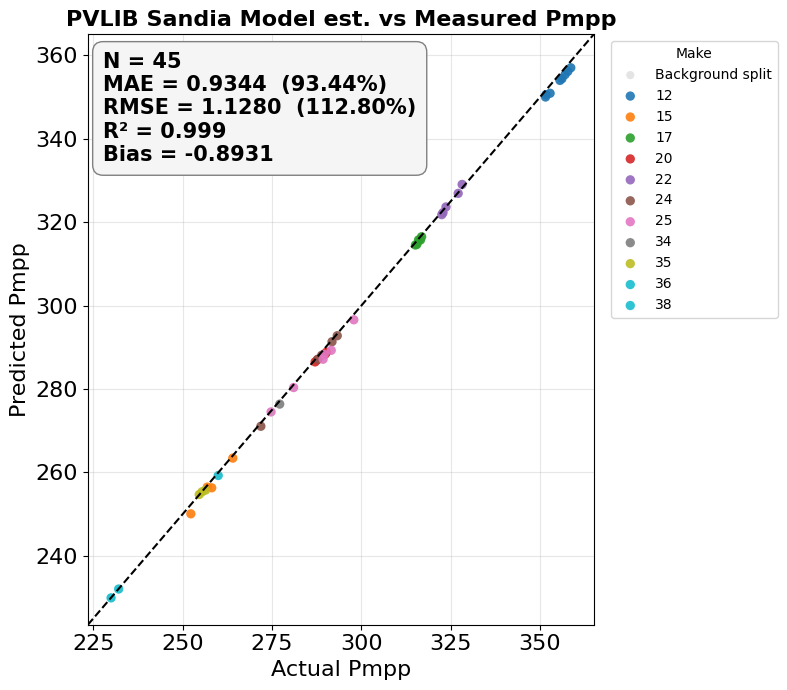

Chart saved to: filtered_dataset_chart.png


In [8]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref7_df,
    background_df=ref7_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="Pmpp_measured_W",
    pred_col="Pmpp_diode_W",
    make_col="Make",
    title="PVLIB Sandia Model est. vs Measured Pmpp",
    xlabel="Actual Pmpp",
    ylabel="Predicted Pmpp",
    save_path="filtered_dataset_chart.png"
)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_38468\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


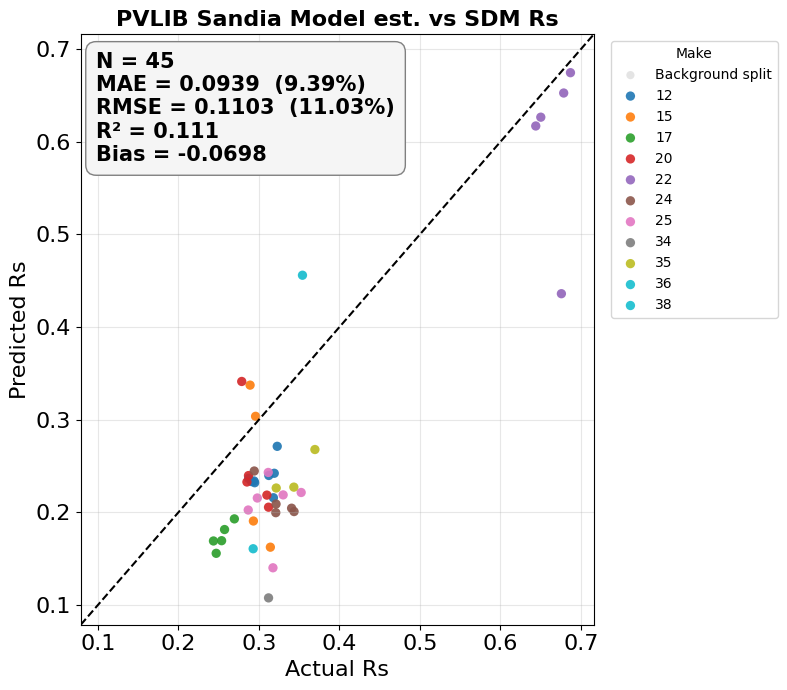

Chart saved to: filtered_dataset_chart.png


In [6]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref7_df,
    background_df=ref7_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="Rs_diode_Ohm",
    pred_col="Rs_pyspice_Ohm",
    make_col="Make",
    title="PVLIB Sandia Model est. vs SDM Rs",
    xlabel="Actual Rs",
    ylabel="Predicted Rs",
    save_path="filtered_dataset_chart.png"
)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_38468\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


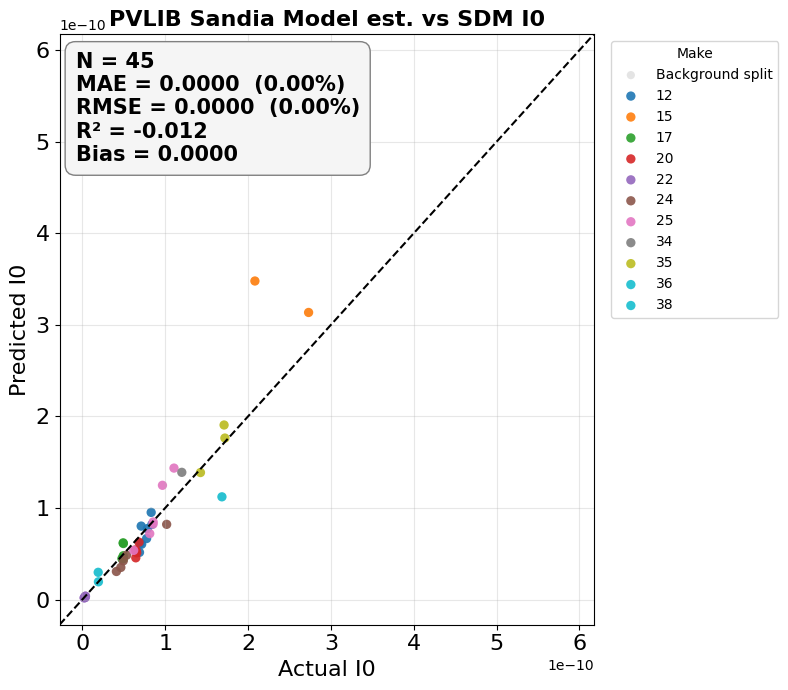

Chart saved to: filtered_dataset_chart.png


In [7]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref7_df,
    background_df=ref7_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="I0_diode_A",
    pred_col="I0_pyspice_A",
    make_col="Make",
    title="PVLIB Sandia Model est. vs SDM I0",
    xlabel="Actual I0",
    ylabel="Predicted I0",
    save_path="filtered_dataset_chart.png"
)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


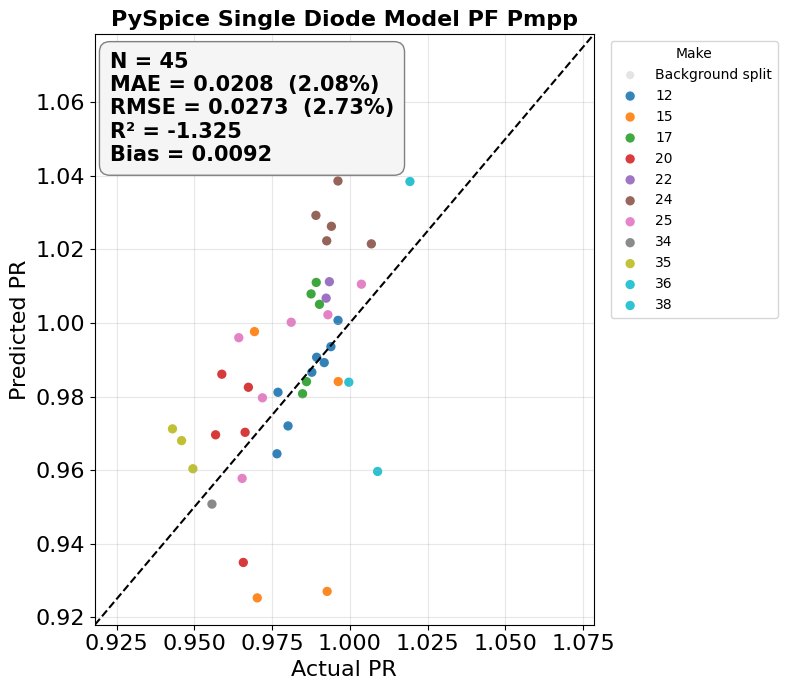

Chart saved to: filtered_dataset_chart.png


In [26]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref7_df,
    background_df=ref7_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="PR_measured",
    pred_col="PR_pyspice",
    make_col="Make",
    title="PySpice Single Diode Model PF Pmpp",
    xlabel="Actual PR",
    ylabel="Predicted PR",
    save_path="filtered_dataset_chart.png"
)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


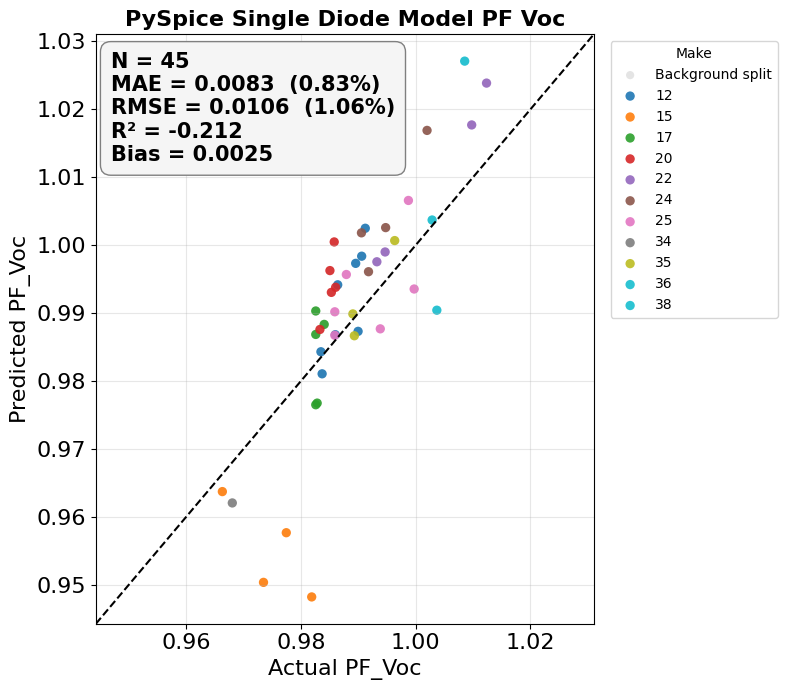

Chart saved to: filtered_dataset_chart.png


In [27]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref7_df,
    background_df=ref7_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="PF_Voc_measured",
    pred_col="PF_Voc_pyspice",
    make_col="Make",
    title="PySpice Single Diode Model PF Voc",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="filtered_dataset_chart.png"
)

In [28]:
FILTERED_OUTPUT8_CSV = "test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"

ref8_df = pd.read_csv(FILTERED_OUTPUT8_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


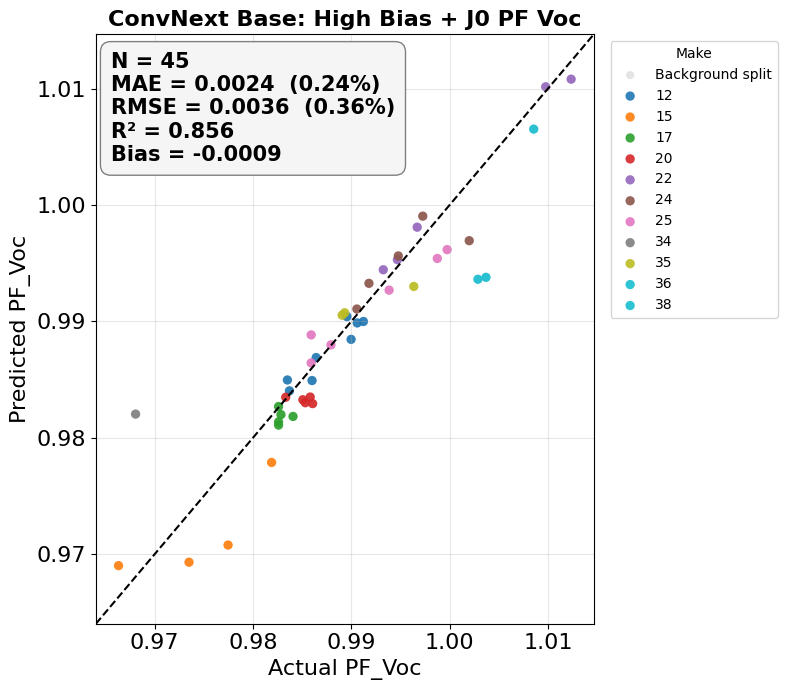

Chart saved to: filtered_dataset_chart.png


In [30]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref8_df,
    background_df=ref8_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_voc",
    pred_col="predicted_pf_voc",
    make_col="Make",
    title="ConvNext Base: High Bias + J0 PF Voc",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="filtered_dataset_chart.png"
)

In [ ]:
test_predictions_convnext_base_highbias_PF_Voc_fixedsplit

In [38]:
FILTERED_OUTPUT9_CSV = "test_predictions_convnext_base_highbias_PF_Voc_fixedsplit_filtered.csv"

ref9_df = pd.read_csv(FILTERED_OUTPUT9_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


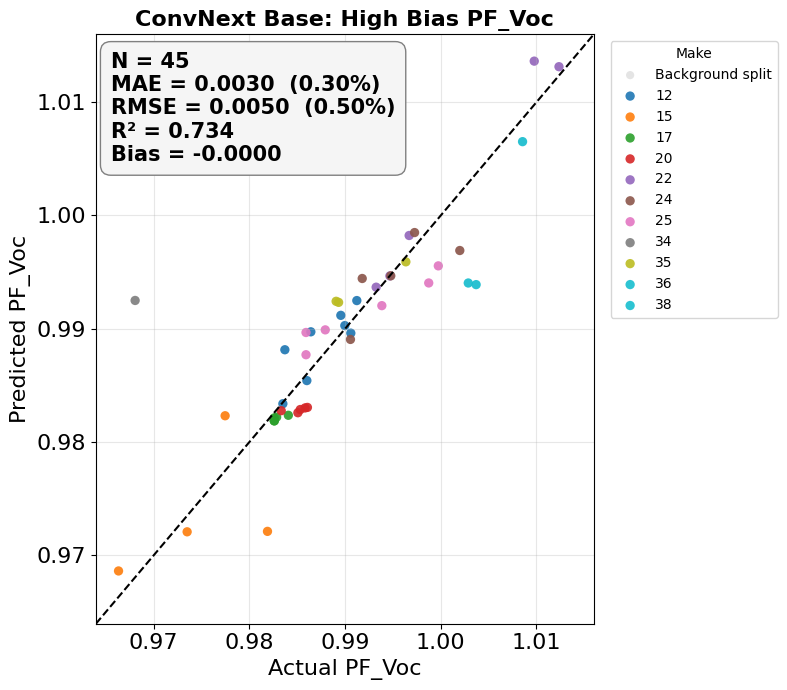

Chart saved to: filtered_dataset_chart.png


In [40]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref9_df,
    background_df=ref9_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_voc",
    pred_col="predicted_pf_voc",
    make_col="Make",
    title="ConvNext Base: High Bias PF_Voc",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="filtered_dataset_chart.png"
)

In [47]:
FILTERED_OUTPUT10_CSV = "test_predictions_convnext_base_highbias_j0_PF_Voc_trainnorm_fixedsplit.csv"

ref10_df = pd.read_csv(FILTERED_OUTPUT10_CSV)

In [ ]:
import matplotlib.pyplot as plt

std = df['actual_pr'].std()
print("Standar deviasi:", std)

df['actual_pr'].hist(bins=20)
plt.xlabel("Performance Ratio (actual)")
plt.ylabel("Jumlah")
plt.title(f"Distribusi PR aktual (std = {std:.4f})")
plt.show()

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


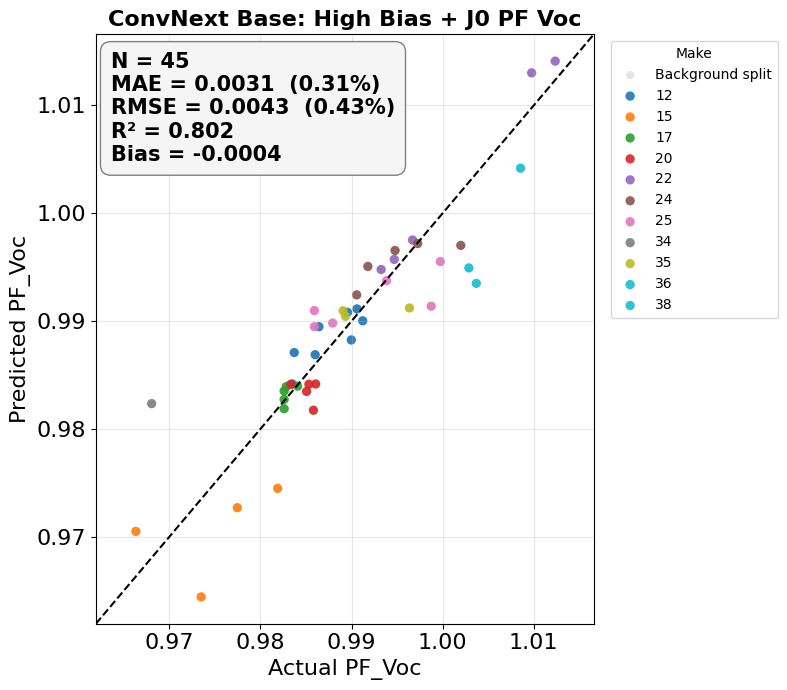

Chart saved to: filtered_dataset_chart.png


In [36]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref10_df,
    background_df=ref10_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_voc",
    pred_col="predicted_pf_voc",
    make_col="Make",
    title="ConvNext Base: High Bias + J0 PF Voc",
    xlabel="Actual PF_Voc",
    ylabel="Predicted PF_Voc",
    save_path="filtered_dataset_chart.png"
)

In [42]:
FILTERED_OUTPUT11_CSV = "test_predictions_convnext_base_highbias_j0_general3438.csv"

ref11_df = pd.read_csv(FILTERED_OUTPUT11_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


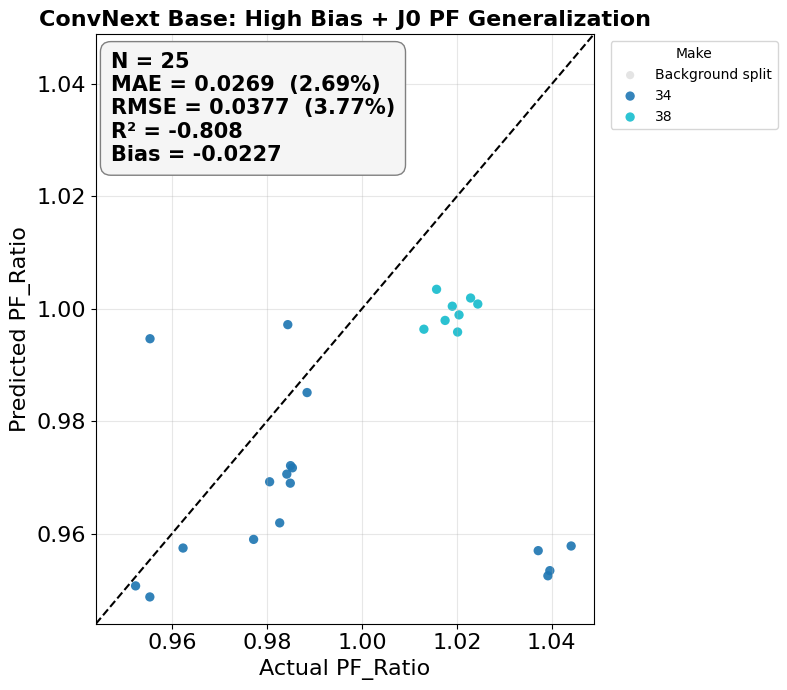

Chart saved to: filtered_dataset_chart.png


In [46]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref11_df,
    background_df=ref11_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="ConvNext Base: High Bias + J0 PF Generalization",
    xlabel="Actual PF_Ratio",
    ylabel="Predicted PF_Ratio",
    save_path="filtered_dataset_chart.png"
)

In [44]:
FILTERED_OUTPUT12_CSV = "test_predictions_convnext_base_highbias_general3438_filtered.csv"

ref12_df = pd.read_csv(FILTERED_OUTPUT12_CSV)

C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_39764\283921651.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_makes))


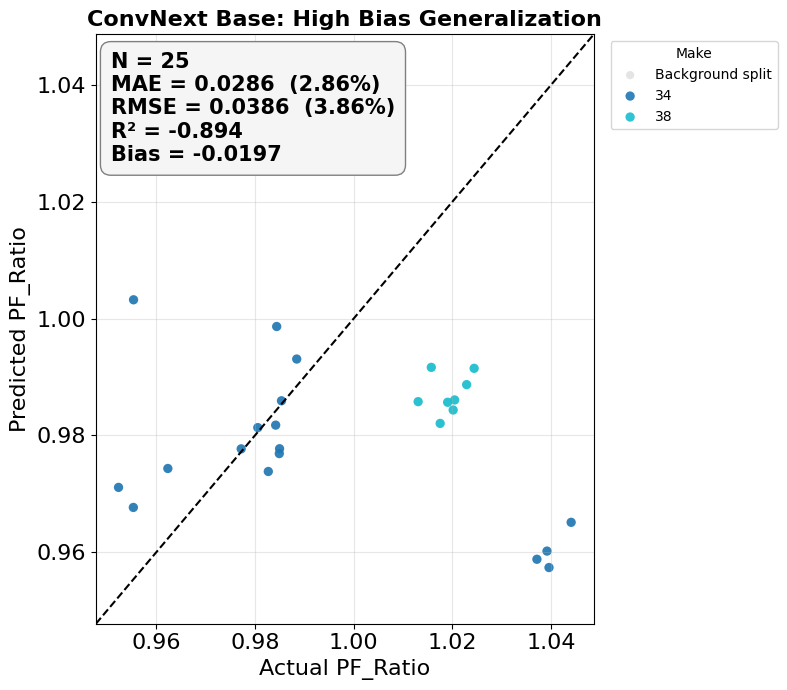

Chart saved to: filtered_dataset_chart.png


In [45]:
plot_actual_vs_predicted_like_top_right(
    plot_df=ref12_df,
    background_df=ref12_df,   # opsional, supaya semua data jadi background abu-abu
    actual_col="actual_pf_ratio",
    pred_col="predicted_pf_ratio",
    make_col="Make",
    title="ConvNext Base: High Bias Generalization",
    xlabel="Actual PF_Ratio",
    ylabel="Predicted PF_Ratio",
    save_path="filtered_dataset_chart.png"
)

In [4]:
import pandas as pd

df = pd.read_csv("AnonDB_80_10_10_seed42.csv")

df_test = df[df["split"].astype(str).str.lower() == "test"].copy()

df_test.to_csv("AnonDB_test_only.csv", index=False)

In [5]:
import pandas as pd

df_test = pd.read_csv("AnonDB_test_only.csv")
df_zub = pd.read_csv("AnonDB_zub.csv", sep=";")

df_test["ELHPath"] = df_test["ELHPath"].astype(str).str.strip()
df_zub["ELHPath"] = df_zub["ELHPath"].astype(str).str.strip()

df_test = df_test.merge(
    df_zub[["ELHPath", "Num_Cells"]].drop_duplicates("ELHPath"),
    on="ELHPath",
    how="left",
)

df_test.to_csv(
    "AnonDB_test_with_Num_Cells.csv",
    index=False,
)

print(df_test[["ELHPath", "Num_Cells"]].head())
print("Num_Cells missing:", df_test["Num_Cells"].isna().sum())

                            ELHPath Num_Cells
0  ./EL/10085_35_1_02222021_80.tiff        60
1  ./EL/10084_35_1_02222021_80.tiff        60
2   ./EL/3893_35_1_02222021_80.tiff        60
3    ./EL/4476_7_1_01172020_80.tiff        60
4   ./EL/3609_24_4_02242021_80.tiff        60
Num_Cells missing: 0


In [6]:
import pandas as pd

# Baca kedua file
df_anon = pd.read_csv("AnonDB_test_with_Num_Cells.csv")
df_pred = pd.read_csv(
    "test_predictions_convnext_base_dual_fixedsplit_filtered.csv"
)

# Kupas ELHPath menjadi module ID
# Contoh:
# ./EL/10085_35_1_02222021_80.tiff
# menjadi:
# 10085_35_1_02222021
df_anon["module"] = (
    df_anon["ELHPath"]
    .astype(str)
    .str.replace("\\", "/", regex=False)
    .str.rsplit("/", n=1)
    .str[-1]
    .str.replace(".tiff", "", regex=False)
    .str.replace(".tif", "", regex=False)
    .str.replace(r"_80$", "", regex=True)
    .str.strip()
)

# Pastikan nama module di file predictions bersih
df_pred["module_id"] = (
    df_pred["module_id"]
    .astype(str)
    .str.strip()
)

# Filter AnonDB hanya untuk module yang ada di predictions
df_filtered = df_anon[
    df_anon["module"].isin(df_pred["module_id"])
].copy()

# Simpan hasil
df_filtered.to_csv(
    "AnonDB_test_with_Num_Cells_filtered.csv",
    index=False
)

print("Jumlah prediction modules:", df_pred["module_id"].nunique())
print("Jumlah baris AnonDB awal:", len(df_anon))
print("Jumlah baris setelah filter:", len(df_filtered))
print("Module unik setelah filter:", df_filtered["module"].nunique())

df_filtered[["module", "ELHPath", "Num_Cells"]].head()

Jumlah prediction modules: 45
Jumlah baris AnonDB awal: 61
Jumlah baris setelah filter: 45
Module unik setelah filter: 45


,module,ELHPath,Num_Cells
0,10085_35_1_02222021,./EL/10085_35_1_02222021_80.tiff,60
1,10084_35_1_02222021,./EL/10084_35_1_02222021_80.tiff,60
2,3893_35_1_02222021,./EL/3893_35_1_02222021_80.tiff,60
4,3609_24_4_02242021,./EL/3609_24_4_02242021_80.tiff,60
5,3603_24_4_02242021,./EL/3603_24_4_02242021_80.tiff,60


In [7]:
target = "4262_20_1_02042021"

print(
    df_anon.loc[
        df_anon["module"].astype(str).str.contains("4262_20_1", na=False),
        ["module", "ELHPath", "Num_Cells"]
    ]
)

                module                          ELHPath Num_Cells
19  4262_20_1_02042021  ./EL/4262_20_1_02042021_80.tiff        60


In [10]:
import numpy as np
import pandas as pd


# ============================================================
# FILES
# ============================================================
RESULTS_CSV = "rajput_pyspice_results_simple.csv"
METADATA_CSV = "AnonDB_test_with_Num_Cells_filtered.csv"
OUTPUT_CSV = "rajput_pyspice_results_with_PR_PF_Voc.csv"


# ============================================================
# READ DATA
# ============================================================
results = pd.read_csv(RESULTS_CSV)
metadata = pd.read_csv(METADATA_CSV, sep=";")

results["module"] = results["module"].astype(str).str.strip()
metadata["module_id"] = metadata["module"].astype(str).str.strip()


# ============================================================
# SELECT NAMEPLATE DATA
# ============================================================
nameplate = metadata[
    [
        "module",
        "Nameplate_Pmp_(W)",
        "Nameplate_Voc_(V)",
    ]
].drop_duplicates(
    subset="module",
    keep="first",
)


# ============================================================
# MERGE
# ============================================================
df_final = results.merge(
    nameplate,
    on="module",
    how="left",
    validate="many_to_one",
)


# Ensure numeric columns
numeric_columns = [
    "Pmpp_measured_W",
    "Pmpp_diode_W",
    "Pmpp_pyspice_W",
    "Voc_measured_V",
    "Voc_diode_V",
    "Voc_pyspice_V",
    "Nameplate_Pmp_(W)",
    "Nameplate_Voc_(V)",
]

for column in numeric_columns:
    df_final[column] = pd.to_numeric(
        df_final[column],
        errors="coerce",
    )


# Prevent division by zero
nameplate_pmp = df_final["Nameplate_Pmp_(W)"].replace(0, np.nan)
nameplate_voc = df_final["Nameplate_Voc_(V)"].replace(0, np.nan)


# ============================================================
# PERFORMANCE RATIOS
# ============================================================
df_final["PR_measured"] = (
    df_final["Pmpp_measured_W"] / nameplate_pmp
)

df_final["PR_diode"] = (
    df_final["Pmpp_diode_W"] / nameplate_pmp
)

df_final["PR_pyspice"] = (
    df_final["Pmpp_pyspice_W"] / nameplate_pmp
)


# ============================================================
# VOC PERFORMANCE FACTORS
# ============================================================
df_final["PF_Voc_measured"] = (
    df_final["Voc_measured_V"] / nameplate_voc
)

df_final["PF_Voc_diode"] = (
    df_final["Voc_diode_V"] / nameplate_voc
)

df_final["PF_Voc_pyspice"] = (
    df_final["Voc_pyspice_V"] / nameplate_voc
)


# ============================================================
# SAVE
# ============================================================
df_final.to_csv(
    OUTPUT_CSV,
    index=False,
)

print("Saved:", OUTPUT_CSV)

display_columns = [
    "module",
    "Nameplate_Pmp_(W)",
    "Pmpp_measured_W",
    "Pmpp_diode_W",
    "Pmpp_pyspice_W",
    "PR_measured",
    "PR_diode",
    "PR_pyspice",
    "Nameplate_Voc_(V)",
    "Voc_measured_V",
    "Voc_diode_V",
    "Voc_pyspice_V",
    "PF_Voc_measured",
    "PF_Voc_diode",
    "PF_Voc_pyspice",
]

display(df_final[display_columns].head())

Saved: rajput_pyspice_results_with_PR_PF_Voc.csv


,module,Nameplate_Pmp_(W),Pmpp_measured_W,Pmpp_diode_W,Pmpp_pyspice_W,PR_measured,PR_diode,PR_pyspice,Nameplate_Voc_(V),Voc_measured_V,Voc_diode_V,Voc_pyspice_V,PF_Voc_measured,PF_Voc_diode,PF_Voc_pyspice
0,10084_35_1_02222021,270,256.368305,255.728471,259.300743,0.949512,0.947142,0.960373,38.4,37.99,38.021764,37.888355,0.989323,0.990150,0.986676
1,10085_35_1_02222021,270,255.383427,255.314702,261.364659,0.945865,0.945610,0.968017,38.4,37.98,38.011756,38.011756,0.989062,0.989889,0.989889
2,10105_24_3_03012021,290,287.833916,287.142120,296.464938,0.992531,0.990145,1.022293,40.2,39.87,40.043348,40.043348,0.991791,0.996103,0.996103
3,10196_24_3_03012021,290,288.881370,288.067224,301.180456,0.996143,0.993335,1.038553,40.2,39.99,40.163870,40.304303,0.994776,0.999101,1.002595
4,2532_36_1_08062019,230,232.045963,231.996074,220.717727,1.008895,1.008679,0.959642,48.7,48.88,48.920870,48.234261,1.003696,1.004535,0.990437


In [19]:
import os
import pandas as pd


rajput_file = "rajput_pyspice_results_with_PR_PF_Voc.csv"
prediction_file = (
    "test_predictions_effnet_b1_highbias_j0_logtrainnorm_fixedsplit.csv"
)
output_file = "rajput_results_with_PR_PF_Voc_make.csv"


df_rajput = pd.read_csv(rajput_file)
df_prediction = pd.read_csv(prediction_file)


# Bersihkan module pada hasil Rajput
df_rajput["module"] = (
    df_rajput["module"]
    .astype(str)
    .str.strip()
)


# Contoh:
# C:\...\J0_Rs\10085_35_1_02222021_J0.tiff
# menjadi:
# 10085_35_1_02222021
df_prediction["module"] = (
    df_prediction["j0_path"]
    .astype(str)
    .apply(lambda path: os.path.basename(path))
    .str.replace("_J0.tiff", "", regex=False)
    .str.replace("_J0.tif", "", regex=False)
    .str.strip()
)


print(
    df_prediction[
        ["j0_path", "module", "Make"]
    ].head()
)


make_lookup = (
    df_prediction[
        ["module", "Make"]
    ]
    .drop_duplicates(
        subset="module",
        keep="first",
    )
)


df_final = df_rajput.merge(
    make_lookup,
    on="module",
    how="left",
    validate="many_to_one",
)


df_final.to_csv(
    output_file,
    index=False,
)

print("\nSaved:", output_file)
print("Total rows:", len(df_final))
print("Missing Make:", df_final["Make"].isna().sum())

                                             j0_path               module  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  10085_35_1_02222021   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  10084_35_1_02222021   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   3893_35_1_02222021   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   3609_24_4_02242021   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   3603_24_4_02242021   

   Make  
0    35  
1    35  
2    35  
3    24  
4    24  

Saved: rajput_results_with_PR_PF_Voc_make.csv
Total rows: 45
Missing Make: 0
